In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import r2_score

In [4]:
X, y = make_regression(
    n_samples=200,
    n_features=20,
    n_informative=10,
    noise=40,
    random_state=42
)

In [5]:
columns = [f"Feature_{i}" for i in range(1,21)]

df = pd.DataFrame(X, columns=columns)

df["Target"] = y

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Target
0,0.198085,-0.144360,0.059218,-0.272724,-0.335785,-0.230935,0.013929,-1.503143,-0.245743,-0.054295,...,1.126565,-1.106526,-0.259591,-2.696887,-0.024125,2.573360,1.848956,1.669022,-0.268889,-245.559260
1,-0.968046,-0.310308,-0.397558,1.171718,-0.399899,1.181891,1.237654,0.182501,-0.670115,0.487560,...,-0.528297,-1.422975,-0.044893,-1.176173,0.379768,-0.970124,-0.202524,0.269295,1.036088,-24.581201
2,-0.388177,0.170416,-0.337086,-1.975467,0.056650,-1.209695,-0.613403,0.486502,0.064474,-0.144088,...,1.218762,1.490726,-0.070499,-0.939335,-0.302470,0.148667,1.530751,0.529693,-0.213443,-89.293814
3,0.513908,0.179582,1.938929,1.187679,0.403730,0.283288,-1.000331,0.324359,-1.179040,0.201160,...,-0.474904,-1.345980,-0.903702,-0.464617,-0.677745,0.126380,0.586694,-0.024196,0.871297,-115.015179
4,-0.552223,0.632932,-0.570746,0.492451,-0.049464,-0.637740,-0.832356,0.382410,0.166452,2.455300,...,-0.555477,1.189017,-1.122722,0.289169,0.471416,1.420504,-0.623141,0.674819,-0.637387,15.282627


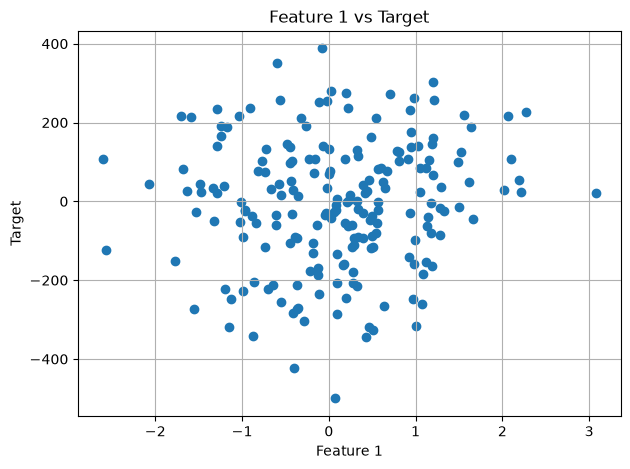

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0], y)

plt.xlabel("Feature 1")
plt.ylabel("Target")

plt.title("Feature 1 vs Target")

plt.grid()

plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R² Score")

print(r2_score(y_test, y_pred_lr))

Linear Regression R² Score
0.9303705456631096


In [10]:
ridge = Ridge(alpha=10)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression R² Score")

print(r2_score(y_test, y_pred_ridge))

Ridge Regression R² Score
0.9337922626059789


In [11]:
lasso = Lasso(alpha=0.5)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression R² Score")

print(r2_score(y_test, y_pred_lasso))

Lasso Regression R² Score
0.9316479720261858


In [12]:
print("Linear Regression :", r2_score(y_test, y_pred_lr))

print("Ridge Regression :", r2_score(y_test, y_pred_ridge))

print("Lasso Regression :", r2_score(y_test, y_pred_lasso))

Linear Regression : 0.9303705456631096
Ridge Regression : 0.9337922626059789
Lasso Regression : 0.9316479720261858


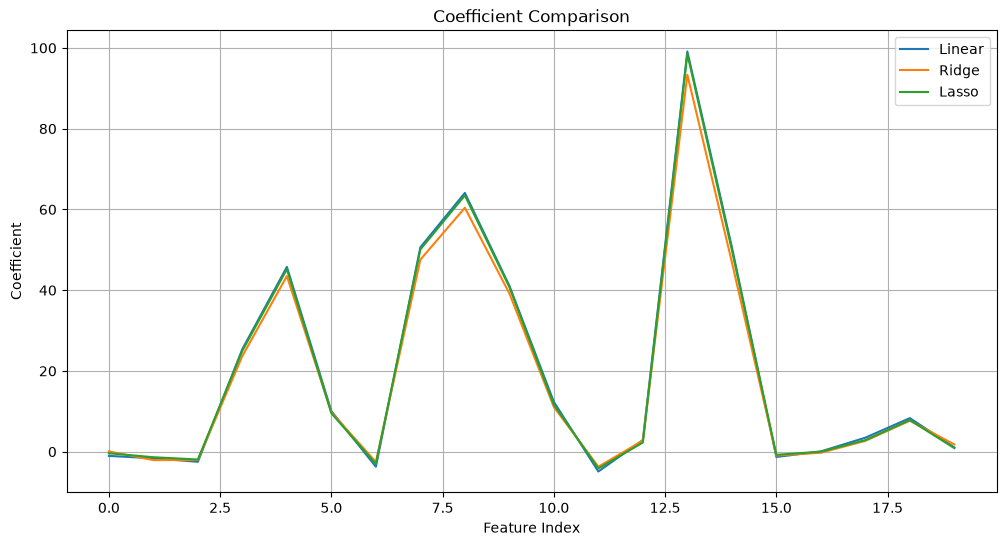

In [13]:
plt.figure(figsize=(12,6))

plt.plot(lr.coef_, label="Linear")

plt.plot(ridge.coef_, label="Ridge")

plt.plot(lasso.coef_, label="Lasso")

plt.xlabel("Feature Index")

plt.ylabel("Coefficient")

plt.title("Coefficient Comparison")

plt.legend()

plt.grid()

plt.show()

In [14]:
print("Total Features :", len(lasso.coef_))

print("Selected Features :", np.sum(lasso.coef_ != 0))

print("Removed Features :", np.sum(lasso.coef_ == 0))

Total Features : 20
Selected Features : 19
Removed Features : 1


In [15]:
feature_names = [f"Feature_{i}" for i in range(1,21)]

print("Selected Features\n")

for feature, coef in zip(feature_names, lasso.coef_):

    if coef != 0:

        print(feature, "=", round(coef,3))

Selected Features

Feature_1 = -0.392
Feature_2 = -1.37
Feature_3 = -1.938
Feature_4 = 25.006
Feature_5 = 45.197
Feature_6 = 9.521
Feature_7 = -3.014
Feature_8 = 50.087
Feature_9 = 63.467
Feature_10 = 40.794
Feature_11 = 11.625
Feature_12 = -4.148
Feature_13 = 2.272
Feature_14 = 98.525
Feature_15 = 49.969
Feature_16 = -0.772
Feature_18 = 2.872
Feature_19 = 7.827
Feature_20 = 0.881


In [16]:
print("Removed Features\n")

for feature, coef in zip(feature_names, lasso.coef_):

    if coef == 0:

        print(feature)

Removed Features

Feature_17


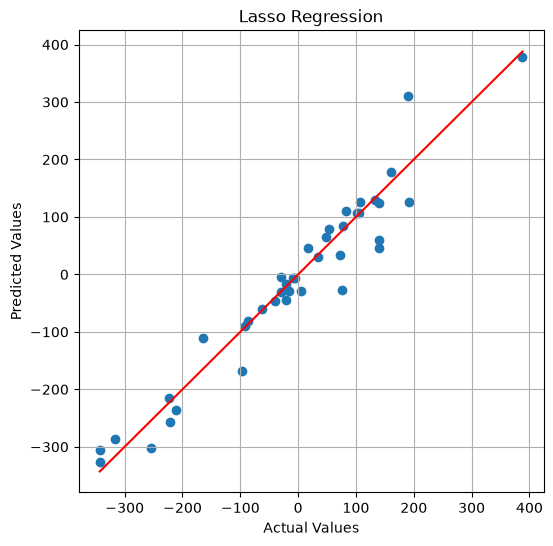

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lasso)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Lasso Regression")

plt.grid()

plt.show()

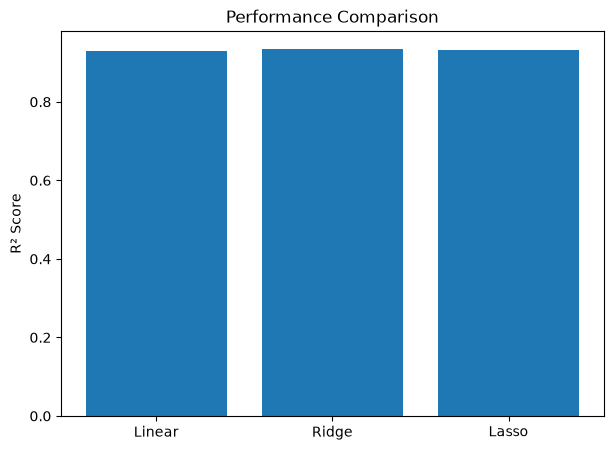

In [18]:
models = ["Linear", "Ridge", "Lasso"]

scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso)
]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.ylabel("R² Score")

plt.title("Performance Comparison")

plt.show()

In [19]:
alphas = [0.001,0.01,0.1,1,10,100]

scores = []

for a in alphas:

    model = Lasso(alpha=a)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    scores.append(r2_score(y_test,pred))

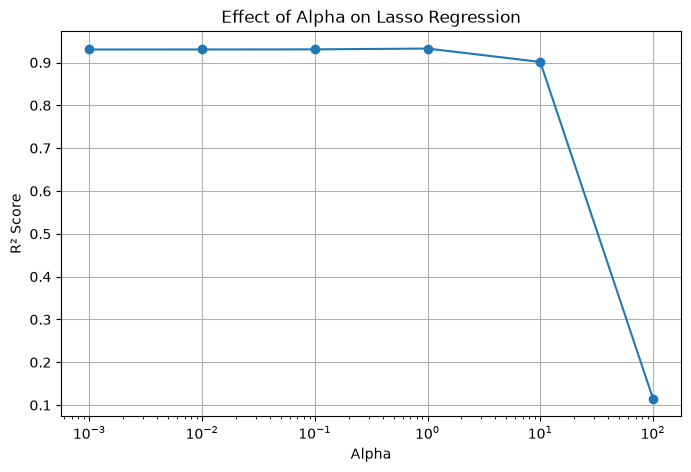

In [20]:
plt.figure(figsize=(8,5))

plt.plot(alphas,scores,marker='o')

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("R² Score")

plt.title("Effect of Alpha on Lasso Regression")

plt.grid()

plt.show()

In [21]:
remaining = []

for a in alphas:

    model = Lasso(alpha=a)

    model.fit(X_train,y_train)

    remaining.append(np.sum(model.coef_ != 0))

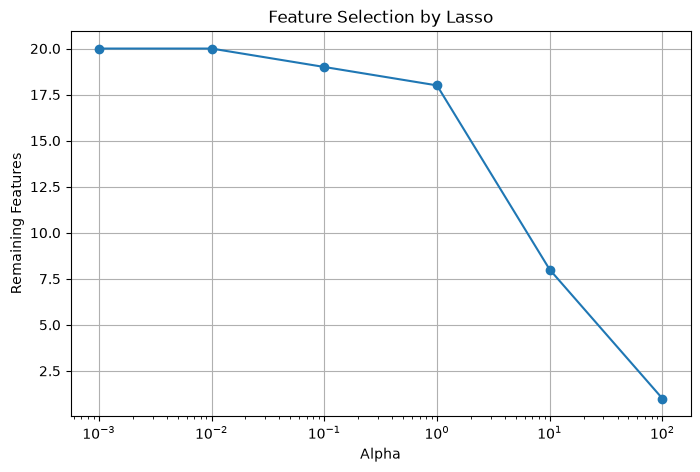

In [22]:
plt.figure(figsize=(8,5))

plt.plot(alphas,remaining,marker='o')

plt.xscale("log")

plt.xlabel("Alpha")

plt.ylabel("Remaining Features")

plt.title("Feature Selection by Lasso")

plt.grid()

plt.show()